# **German Electricity Demand  Forecasting the Weekend Load Regime**

## Environment

The next cell tops up only the packages a fresh runtime is missing - on Colab
that is usually just `holidays`.

In [1]:
# 1. only install what the runtime is actually missing
import importlib.util, subprocess, sys, os

# 2. force TensorFlow onto the CPU BEFORE it is imported anywhere. On flaky Colab
#    GPU runtimes the LSTM cast kernel can die with an InternalError (cuLaunchKernel);
#    this model is small, so CPU is quick and the neural result is reproducible.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# 3. the seed that makes every number below survive a kernel restart
RNG_SEED = 19

# 4. walk the dependency list and pip-install any gap
for _pkg, _mod in [("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib"),
                   ("statsmodels", "statsmodels"), ("scikit-learn", "sklearn"),
                   ("requests", "requests"), ("holidays", "holidays"),
                   ("joblib", "joblib"), ("tensorflow", "tensorflow")]:
    if importlib.util.find_spec(_mod) is None:
        print("installing", _pkg, "...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=True)
print("environment ready")

# 5. import TensorFlow and confirm no GPU is visible (CPU run by design)
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} | visible GPUs: {len(gpus)} (CPU run by design)")
tf.random.set_seed(RNG_SEED)
tf.keras.utils.set_random_seed(RNG_SEED)

environment ready
TensorFlow 2.20.0 | visible GPUs: 0 (CPU run by design)


In [2]:
# 1. the scientific stack, imported once
import io, math, time, random, hashlib, warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import requests

# 2. the SARIMA grid mutters ConvergenceWarnings all day; silence them here
warnings.filterwarnings("ignore")

# 3. load the dice on every RNG we touch
os.environ["PYTHONHASHSEED"] = str(RNG_SEED)
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# 4. the modelling constants that stay fixed for the whole route
WK_ANCHOR = "W"           # weekly bins labelled on Sunday, so each week owns its Sat+Sun
SEASON = 52               # one year of weeks
SPAN = 104                # trial window: the final 104 weeks, in time order
LOOKBACK = 168            # LSTM look-back: one week of hours
HDD_BASE, CDD_BASE = 16.0, 22.0   # degree-day bases for Legs 4-5
FAST_RUN = False          # True shrinks the SARIMA grid to p,q in [0,3] for quick
                          # iteration ONLY; the submission run needs FAST_RUN = False

# 5. file names and the German load column
CSV_NAME = "time_series_60min_singleindex.csv"
OPSD_URL = ("https://data.open-power-system-data.org/time_series/2020-10-06/"
            "time_series_60min_singleindex.csv")
LOAD_COL = "DE_load_actual_entsoe_transparency"
TEMP_CACHE = "berlin_daily_temperature.csv"

print(f"seed={RNG_SEED} anchor={WK_ANCHOR} season={SEASON} span={SPAN} "
      f"degree-day bases={HDD_BASE}/{CDD_BASE} FAST_RUN={FAST_RUN}")

seed=19 anchor=W season=52 span=104 degree-day bases=16.0/22.0 FAST_RUN=False


In [3]:
# 1. a frozen theme resolved from a NEUTRAL hash key, never from a name
@dataclass(frozen=True)
class Theme:
    key: str
    seed: int
    primary: str
    secondary: str
    supports: tuple
    fig_w: float
    line_w: float
    upper_titles: bool
    ylab_mode: int

    @property
    def palette(self):
        # primary + secondary lead, muted supports follow
        return [self.primary, self.secondary, *self.supports]


def resolve_weekend_theme_m19(key="weekend_key_19"):
    """Steel-coral theme, every knob derived from the hash of a neutral key."""
    # 2. hash the key into a small integer that seeds the cosmetic choices
    h = int(hashlib.sha256(key.encode()).hexdigest()[:8], 16)
    return Theme(
        key=key, seed=h,
        primary="#2f6f8f",          # steel blue
        secondary="#e2725b",        # coral
        supports=("#6b8f9c", "#b5651d", "#4a5d68", "#d9a679"),
        fig_w=11.0,
        line_w=1.4 + (h % 5) * 0.12,
        upper_titles=(h % 2 == 0),
        ylab_mode=h % 3,
    )


THEME = resolve_weekend_theme_m19()

# 3. push the theme into matplotlib once so every figure inherits it
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Verdana", "DejaVu Sans"],
    "axes.prop_cycle": mpl.cycler(color=THEME.palette),
    "figure.figsize": (THEME.fig_w, 4.2),
    "figure.facecolor": "white",
    "axes.titlesize": 12,
    "lines.linewidth": THEME.line_w,
})


def _headline_m19(ax, text):
    # 4. the key decided the casing once; every title obeys it
    ax.set_title(text.upper() if THEME.upper_titles else text)


def _gw_axis_m19(ax):
    labels = ["Load (GW)", "Weekend demand [GW]", "GW"]
    ax.set_ylabel(labels[THEME.ylab_mode])


print("theme:", THEME.key, "| seed", THEME.seed, "| figw", THEME.fig_w,
      "| lw", round(THEME.line_w, 2), "| upper-case titles:", THEME.upper_titles)

theme: weekend_key_19 | seed 1759974292 | figw 11.0 | lw 1.64 | upper-case titles: True


## Data, EDA and stationarity (Part 1)

In [4]:
def _fetch_csv_m19(name=CSV_NAME, url=OPSD_URL):
    """Return the path to the OPSD CSV, streaming the download only if it is absent."""
    # 1. reuse a local copy so a fresh clone does not re-download 130 MB
    if os.path.exists(name):
        print("data file already present:", name)
        return name
    # 2. otherwise stream it down in 1 MB chunks with a light progress print
    print("downloading OPSD 60-minute file (~130 MB) ...")
    with requests.get(url, stream=True, timeout=30) as resp:
        resp.raise_for_status()
        got = 0
        with open(name, "wb") as fh:
            for chunk in resp.iter_content(chunk_size=1 << 20):
                fh.write(chunk)
                got += len(chunk)
                if got % (20 << 20) < (1 << 20):
                    print(f"  {got / 1e6:,.0f} MB", flush=True)
    print("download complete:", name)
    return name


csv_path = _fetch_csv_m19()

downloading OPSD 60-minute file (~130 MB) ...
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  0 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  1 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  21 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  22 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  42 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  43 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 MB
  63 M

In [5]:
def _hourly_m19(path):
    """German hourly load from 2015 onward, in GW, on Berlin local time."""
    # 1. read only the two columns we need and index on the UTC stamp
    raw = pd.read_csv(path, usecols=["utc_timestamp", LOAD_COL],
                      parse_dates=["utc_timestamp"], index_col="utc_timestamp")
    # 2. slice from 2015 IN UTC first, before touching the timezone
    raw = raw.loc["2015-01-01":, LOAD_COL]
    # 3. now convert to Berlin local time and drop the tz label
    raw.index = raw.index.tz_convert("Europe/Berlin").tz_localize(None)
    # 4. bridge short sensor blips, not real outages
    raw = raw.interpolate(method="time", limit=6)
    # 5. MW to GW
    return (raw / 1000.0).rename("load_gw")


load_h = _hourly_m19(csv_path)
print(f"hourly series: {len(load_h):,} rows | {load_h.index[0]} -> {load_h.index[-1]}")
print(f"missing after short-gap interpolation: {int(load_h.isna().sum())}")

hourly series: 50,400 rows | 2015-01-01 01:00:00 -> 2020-10-01 01:00:00
missing after short-gap interpolation: 0


In [6]:
def weekend_frame_m19(hourly, anchor=WK_ANCHOR, min_weekend_hours=40):
    """The lens: mean hourly load over Saturday and Sunday hours only, per week.

    A weekend holds about 48 hours; a week survives only when at least
    `min_weekend_hours` of them are observed, so boundary stubs are dropped.
    Returns (weekend weekly mean, weekend daily mean series).
    """
    # 1. keep only weekend hours: Saturday is dayofweek 5, Sunday is 6
    wknd = hourly[hourly.index.dayofweek >= 5]
    # 2. a weekend daily companion, for the exploratory sawtooth plot
    daily = wknd.resample("D").mean().dropna().rename("wknd_d")
    # 3. weekly mean over the weekend hours, on the Sunday-ending anchor
    by_week = wknd.resample(anchor)
    wk_mean, wk_n = by_week.mean(), by_week.count()
    # 4. drop weeks whose weekend was only partly observed
    kept = wk_mean[wk_n >= min_weekend_hours].rename("wknd_w")
    dropped = int((wk_n < min_weekend_hours).sum())
    print(f"weekend_frame_m19: kept {len(kept)} weeks with a near-complete weekend, "
          f"dropped {dropped} partial weeks")
    return kept, daily


wknd_w, wknd_d = weekend_frame_m19(load_h)

# 5. show the divergence honestly: the weekend lens sits well below the plain mean
_full_wk = load_h.resample(WK_ANCHOR).mean()[
    load_h.resample(WK_ANCHOR).count() >= 160]
print(f"weekend-only lens: mean level {wknd_w.mean():.2f} GW | "
      f"plain full-week mean sits at {_full_wk.mean():.2f} GW | "
      f"gap {_full_wk.mean() - wknd_w.mean():.2f} GW below")
print(wknd_w.describe().round(2))

weekend_frame_m19: kept 300 weeks with a near-complete weekend, dropped 0 partial weeks
weekend-only lens: mean level 47.86 GW | plain full-week mean sits at 55.51 GW | gap 7.65 GW below
count    300.00
mean      47.86
std        3.34
min       40.99
25%       45.25
50%       47.05
75%       50.71
max       56.13
Name: wknd_w, dtype: float64


### Exploratory plots

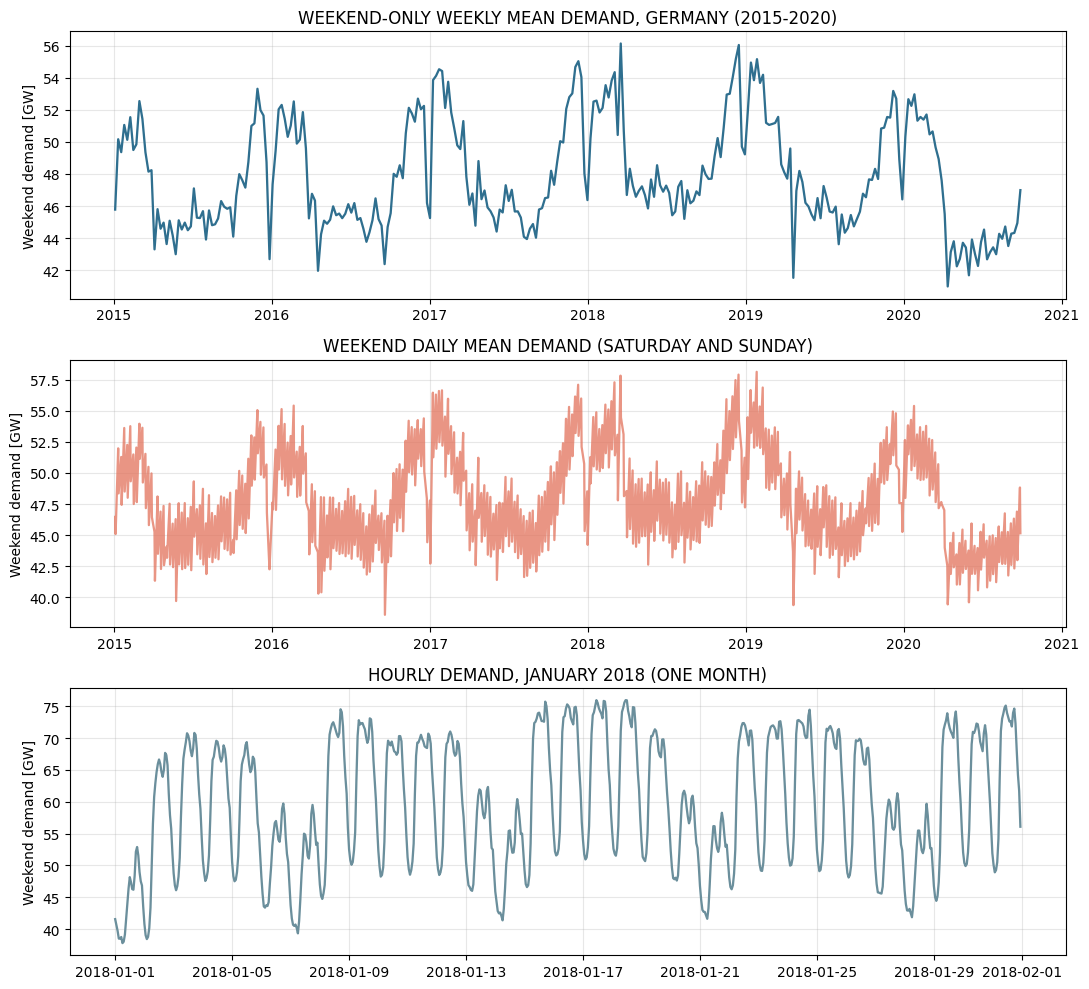

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(THEME.fig_w, 10), sharex=False)
# 1. the headline lens: winter high, summer low, the 2020 dip at the right edge
axes[0].plot(wknd_w.index, wknd_w.values, color=THEME.primary)
_headline_m19(axes[0], "Weekend-only weekly mean demand, Germany (2015-2020)")
# 2. the weekend daily means, showing the Sat/Sun texture
axes[1].plot(wknd_d.index, wknd_d.values, color=THEME.secondary, alpha=0.75)
_headline_m19(axes[1], "Weekend daily mean demand (Saturday and Sunday)")
# 3. one raw hourly month for context on where the weekend hours come from
one_month = load_h.loc["2018-01"]
axes[2].plot(one_month.index, one_month.values, color=THEME.supports[0])
_headline_m19(axes[2], "Hourly demand, January 2018 (one month)")
for ax in axes:
    _gw_axis_m19(ax)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Seasonal decomposition

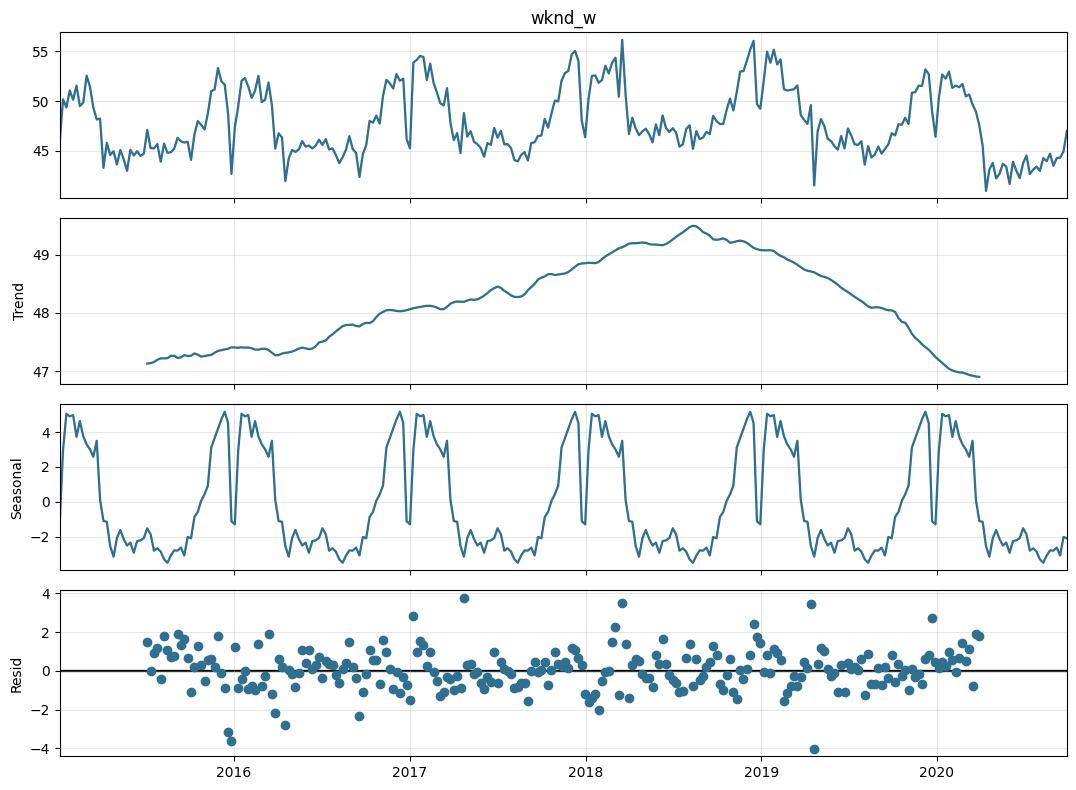

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. additive split at the annual weekly period
pieces = seasonal_decompose(wknd_w, model="additive", period=SEASON)
fig = pieces.plot()
fig.set_size_inches(THEME.fig_w, 8)
for ax in fig.axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Stationarity battery

In [9]:
from statsmodels.tsa.stattools import adfuller


def probe_stationarity_m19(series_map):
    """ADF on each named variant; prints a verdict table, returns {label: p}."""
    got = {}
    print(f"{'variant':<28}{'ADF stat':>10}{'p-value':>12}{'verdict':>18}")
    for label, ser in series_map.items():
        # 1. positional unpack of statistic and p-value survives version drift
        res = adfuller(ser.dropna(), autolag="AIC")
        stat, pval = res[0], res[1]
        verdict = "stationary" if pval < 0.05 else "non-stationary"
        print(f"{label:<28}{stat:>10.3f}{pval:>12.4g}{verdict:>18}")
        got[label] = pval
    return got


adf_p = probe_stationarity_m19({
    "level": wknd_w,
    "first diff (d=1)": wknd_w.diff(),
    "seasonal diff (D=1, 52)": wknd_w.diff(SEASON),
    "first + seasonal diff": wknd_w.diff().diff(SEASON),
})

variant                       ADF stat     p-value           verdict
level                           -4.870    3.99e-05        stationary
first diff (d=1)               -15.251   5.016e-28        stationary
seasonal diff (D=1, 52)         -4.757   6.566e-05        stationary
first + seasonal diff           -5.617   1.165e-06        stationary


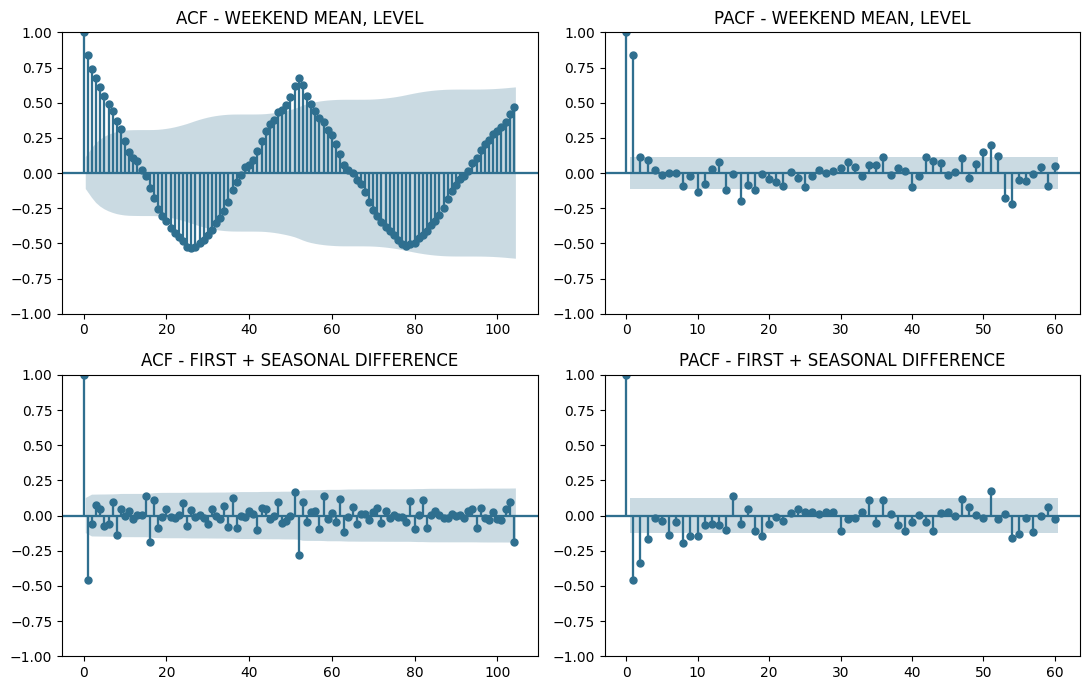

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. the doubly differenced series is what the SARIMA hypothesis rests on
both_d = wknd_w.diff().diff(SEASON).dropna()
fig, axes = plt.subplots(2, 2, figsize=(THEME.fig_w, 7))
plot_acf(wknd_w, lags=104, ax=axes[0, 0])
_headline_m19(axes[0, 0], "ACF - weekend mean, level")
plot_pacf(wknd_w, lags=60, method="ywm", ax=axes[0, 1])
_headline_m19(axes[0, 1], "PACF - weekend mean, level")
plot_acf(both_d, lags=104, ax=axes[1, 0])
_headline_m19(axes[1, 0], "ACF - first + seasonal difference")
plot_pacf(both_d, lags=60, method="ywm", ax=axes[1, 1])
_headline_m19(axes[1, 1], "PACF - first + seasonal difference")
plt.tight_layout()
plt.show()

### Reading the battery honestly


In [11]:
# 1. the fence: everything before the final 104 weeks trains, the rest judges
train_seg, trial_seg = wknd_w.iloc[:-SPAN], wknd_w.iloc[-SPAN:]
print(f"train: {len(train_seg)} weeks | {train_seg.index[0].date()} -> "
      f"{train_seg.index[-1].date()}")
print(f"trial: {len(trial_seg)} weeks | {trial_seg.index[0].date()} -> "
      f"{trial_seg.index[-1].date()}")

train: 196 weeks | 2015-01-04 -> 2018-09-30
trial: 104 weeks | 2018-10-07 -> 2020-09-27


### Metrics used everywhere below

In [12]:
# 1. the MASE scale is learned from the TRAINING history only
SCALE_MASE = train_seg.diff(SEASON).abs().mean()


def score_m19(actual, pred):
    """MAE / RMSE / MASE / Bias for two aligned series."""
    a = np.asarray(actual, dtype=float)
    p = np.asarray(pred, dtype=float)
    gap = p - a
    return {"MAE": float(np.mean(np.abs(gap))),
            "RMSE": float(np.sqrt(np.mean(gap ** 2))),
            "MASE": float(np.mean(np.abs(gap)) / SCALE_MASE),
            "Bias": float(np.mean(gap))}


# 2. one running scoreboard and one dict of every model's 104-week path
scoreboard = []
slate = {}


def post_score_m19(name, actual, pred):
    """Score a model, print the row, and file it on the scoreboard."""
    row = {"model": name, **score_m19(actual, pred)}
    scoreboard.append(row)
    print(f"{name:<28} MAE {row['MAE']:.3f}  RMSE {row['RMSE']:.3f}  "
          f"MASE {row['MASE']:.3f}  Bias {row['Bias']:+.3f}")
    return row


# 3. the self-check: a perfect forecast scores MASE exactly 0
assert score_m19(trial_seg, trial_seg)["MASE"] == 0.0
print(f"MASE denominator (in-sample seasonal-naive MAE): {SCALE_MASE:.3f} GW")

MASE denominator (in-sample seasonal-naive MAE): 1.471 GW


## Benchmark forecasts (Part 2)

In [13]:
def bench_pack_m19(train, index):
    """Build the four benchmark paths over the trial index."""
    h = len(index)
    out = {}
    # 1. the flat liner: the long-run training average, no questions asked
    out["Mean"] = pd.Series(np.full(h, train.mean()), index=index)
    # 2. the stubborn one: last observed week, held forever
    out["Naive"] = pd.Series(np.full(h, train.iloc[-1]), index=index)
    # 3. the calendar believer: whatever this week did last year, tiled forward
    out["Seasonal naive"] = pd.Series(
        np.tile(train.iloc[-SEASON:].values, int(np.ceil(h / SEASON)))[:h], index=index)
    # 4. the ruler-and-pencil trend line
    slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
    out["Drift"] = pd.Series(train.iloc[-1] + slope * np.arange(1, h + 1), index=index)
    return out


packs = bench_pack_m19(train_seg, trial_seg.index)
for name in ["Mean", "Naive", "Seasonal naive", "Drift"]:
    slate[name] = packs[name]
    post_score_m19(name, trial_seg, slate[name])

Mean                         MAE 3.195  RMSE 3.721  MASE 2.172  Bias +0.063
Naive                        MAE 3.206  RMSE 3.724  MASE 2.180  Bias +0.162
Seasonal naive               MAE 1.952  RMSE 2.455  MASE 1.327  Bias +1.381
Drift                        MAE 3.431  RMSE 3.991  MASE 2.333  Bias +0.755


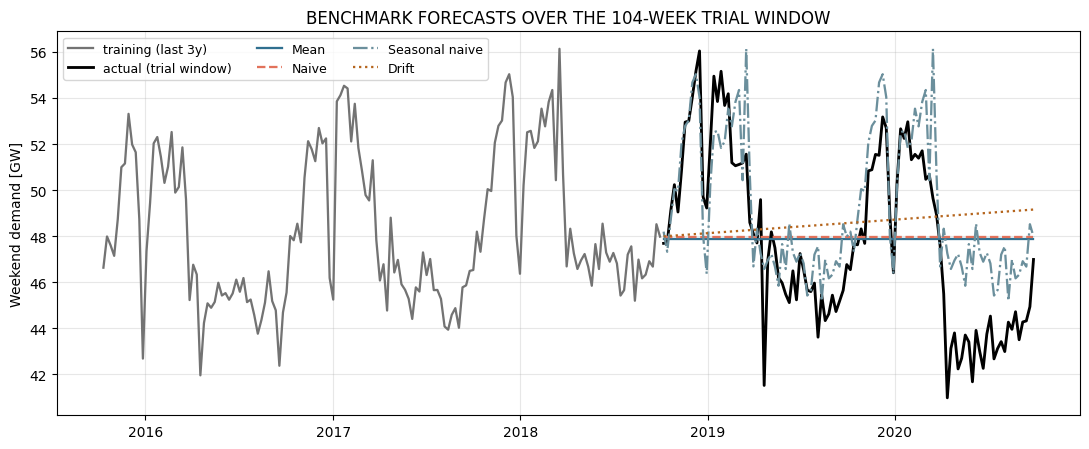

In [14]:
fig, ax = plt.subplots(figsize=(THEME.fig_w, 4.6))
# 1. anchor the eye with the last three training years
ax.plot(train_seg.index[-156:], train_seg.values[-156:], color="0.45",
        label="training (last 3y)")
# 2. the actual trial window in black
ax.plot(trial_seg.index, trial_seg.values, color="black",
        lw=THEME.line_w + 0.4, label="actual (trial window)")
# 3. each benchmark in its own stroke
strokes = ["-", "--", "-.", ":"]
for i, name in enumerate(["Mean", "Naive", "Seasonal naive", "Drift"]):
    ax.plot(trial_seg.index, slate[name].values, strokes[i],
            color=THEME.palette[i], label=name)
_headline_m19(ax, "Benchmark forecasts over the 104-week trial window")
_gw_axis_m19(ax)
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## SARIMA (Part 3)

In [15]:
from joblib import Parallel, delayed, cpu_count
from statsmodels.tsa.statespace.sarimax import SARIMAX


def _screen_one_m19(vals, order, seasonal, maxiter):
    """One screening fit inside a loky worker; returns (order, AIC).

    Workers do NOT inherit the notebook warning filter, so re-silence in here.
    """
    import warnings as _w
    _w.filterwarnings("ignore")
    try:
        from statsmodels.tsa.statespace.sarimax import SARIMAX as _S
        res = _S(vals, order=order, seasonal_order=seasonal,
                 enforce_stationarity=False,
                 enforce_invertibility=False).fit(disp=False, maxiter=maxiter)
        return order, float(res.aic)
    except Exception:
        return order, float("inf")


def sift_orders_m19(train, fast=FAST_RUN, seasonal=(1, 1, 1, SEASON), maxiter=120):
    """Two-stage SARIMA order hunt: parallel AIC screening, then a clean refit."""
    # 1. build the grid; FAST_RUN caps p,q at 3, the submission run at 6
    cap = 3 if fast else 6
    grid = [(p, d, q) for p in range(cap + 1) for d in range(3)
            for q in range(cap + 1)]
    cores = cpu_count()
    vals = train.values.astype(float)
    print(f"sift_orders_m19: {len(grid)} candidate orders x seasonal{seasonal} "
          f"on {cores} cores | screening maxiter={maxiter} | FAST_RUN={fast}")
    # 2. screen in chunks so a long run reports progress and an ETA
    t0 = time.time()
    ranked, done = [], 0
    chunk = max(2 * cores, 8)
    for i in range(0, len(grid), chunk):
        block = grid[i:i + chunk]
        ranked += Parallel(n_jobs=-1)(
            delayed(_screen_one_m19)(vals, o, seasonal, maxiter) for o in block)
        done += len(block)
        gone = time.time() - t0
        eta = gone / done * (len(grid) - done)
        print(f"  screened {done:>3}/{len(grid)} | elapsed {gone/60:5.1f} min "
              f"| ETA {eta/60:5.1f} min", flush=True)
    # 3. rank by AIC and keep the winner
    ranked.sort(key=lambda r: r[1])
    champ, champ_aic = ranked[0]
    print(f"stage 1 winner: order={champ} screening AIC={champ_aic:.2f} "
          f"| total screening time {(time.time()-t0)/60:.1f} min")
    # 4. stage two: refit the winner properly, defaults untouched
    final = SARIMAX(train, order=champ, seasonal_order=seasonal,
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
    print(f"stage 2 refit: AIC={final.aic:.2f}")
    return champ, final, ranked


champ_order, sarima_fit, order_table = sift_orders_m19(train_seg)
print(f"\nselected SARIMA{champ_order}x(1,1,1,{SEASON}) | AIC {sarima_fit.aic:.2f}")
print("top five orders by screening AIC:")
for o, a in order_table[:5]:
    print(f"  {o}: {a:.2f}")

sift_orders_m19: 147 candidate orders x seasonal(1, 1, 1, 52) on 48 cores | screening maxiter=120 | FAST_RUN=False
  screened  96/147 | elapsed   0.8 min | ETA   0.4 min
  screened 147/147 | elapsed   1.8 min | ETA   0.0 min
stage 1 winner: order=(4, 1, 6) screening AIC=296.83 | total screening time 1.8 min


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


stage 2 refit: AIC=297.04

selected SARIMA(4, 1, 6)x(1,1,1,52) | AIC 297.04
top five orders by screening AIC:
  (4, 1, 6): 296.83
  (2, 1, 6): 298.71
  (5, 1, 6): 298.76
  (6, 1, 3): 299.29
  (0, 1, 6): 299.44


### Residual diagnostics

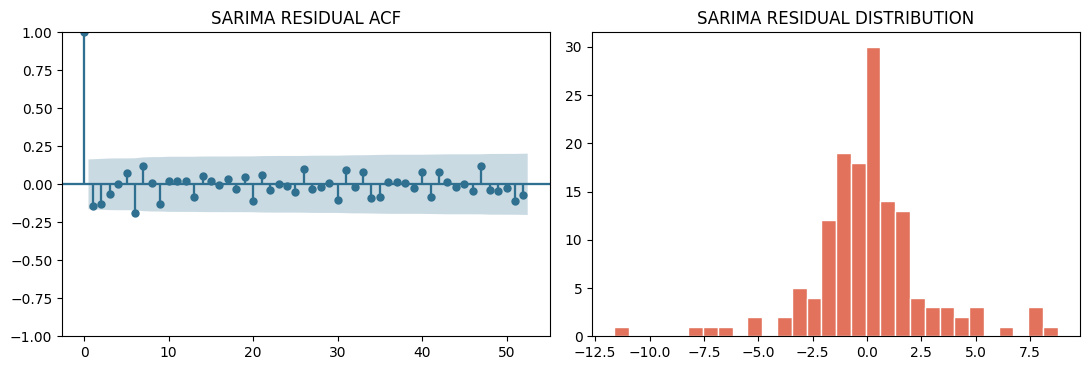

    lb_stat  lb_pvalue
8   14.3828     0.0723
26  24.8031     0.5301
52  45.7494     0.7168
Ljung-Box verdict: residuals look consistent with white noise at the tested lags


In [16]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. skip the seasonal burn-in before reading the residuals
leftovers = sarima_fit.resid.iloc[SEASON + 1:]
fig, axes = plt.subplots(1, 2, figsize=(THEME.fig_w, 3.8))
plot_acf(leftovers, lags=52, ax=axes[0])
_headline_m19(axes[0], "SARIMA residual ACF")
axes[1].hist(leftovers, bins=30, color=THEME.secondary, edgecolor="white")
_headline_m19(axes[1], "SARIMA residual distribution")
plt.tight_layout()
plt.show()

# 2. Ljung-Box at three lags, with an honest verdict
lb = acorr_ljungbox(leftovers, lags=[8, 26, 52], return_df=True)
print(lb.round(4))
print("Ljung-Box verdict:",
      "residuals look consistent with white noise at the tested lags"
      if (lb["lb_pvalue"] > 0.05).all()
      else "some autocorrelation survives - the model is imperfect, and we say so")

### 104-week SARIMA forecast with a 95% interval

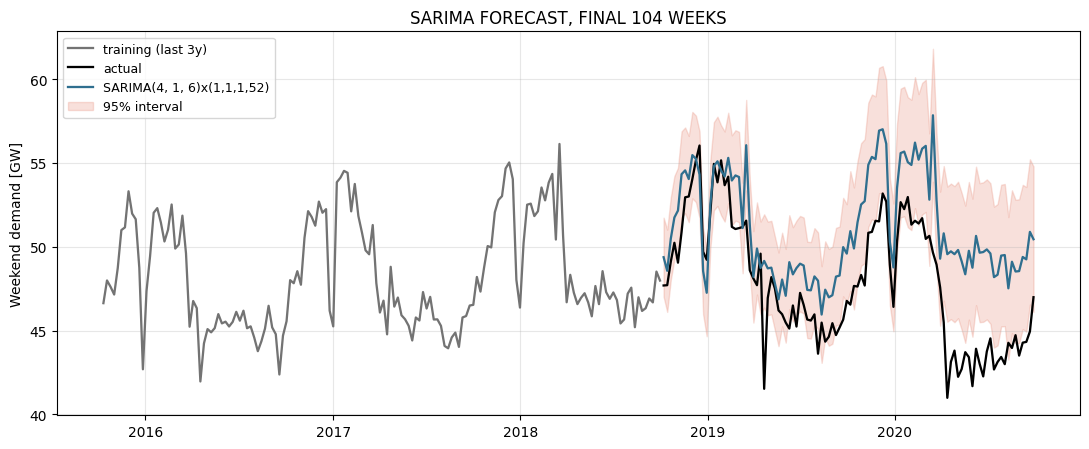

SARIMA                       MAE 3.383  RMSE 3.966  MASE 2.300  Bias +3.258
share of trial actuals inside the 95% band: 52.9%


In [17]:
# 1. forecast the trial horizon and pull the 95% band
sarima_view = sarima_fit.get_forecast(steps=SPAN)
slate["SARIMA"] = pd.Series(sarima_view.predicted_mean.values, index=trial_seg.index)
band = pd.DataFrame(np.asarray(sarima_view.conf_int(alpha=0.05)),
                    index=trial_seg.index, columns=["lo", "hi"])

fig, ax = plt.subplots(figsize=(THEME.fig_w, 4.6))
ax.plot(train_seg.index[-156:], train_seg.values[-156:], color="0.45",
        label="training (last 3y)")
ax.plot(trial_seg.index, trial_seg.values, color="black", label="actual")
ax.plot(trial_seg.index, slate["SARIMA"].values, color=THEME.primary,
        label=f"SARIMA{champ_order}x(1,1,1,{SEASON})")
ax.fill_between(trial_seg.index, band["lo"], band["hi"],
                color=THEME.secondary, alpha=0.22, label="95% interval")
_headline_m19(ax, "SARIMA forecast, final 104 weeks")
_gw_axis_m19(ax)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

post_score_m19("SARIMA", trial_seg, slate["SARIMA"])
inside_95 = ((trial_seg >= band["lo"]) & (trial_seg <= band["hi"])).mean()
print(f"share of trial actuals inside the 95% band: {inside_95:.1%}")

## SARIMAX with Berlin temperature (Part 4)

In [18]:
def _stand_in_temp_m19(index):
    """Deterministic stand-in temperature (labelled SYNTHETIC) for offline runs."""
    # 1. a smooth annual cosine plus mild seeded noise, clearly not real data
    doy = index.dayofyear.values
    rng = np.random.default_rng(RNG_SEED)
    curve = 9.5 - 9.0 * np.cos(2 * np.pi * (doy - 15) / 365.25)
    return pd.Series(curve + rng.normal(0, 2.2, len(index)), index=index, name="temp_c")


def pull_berlin_m19(start, end, cache=TEMP_CACHE):
    """Daily Berlin temperature: cache first, then Open-Meteo, then a labelled fallback."""
    # 1. a cached copy keeps the notebook offline-runnable
    if os.path.exists(cache):
        raw = pd.read_csv(cache, parse_dates=[0], index_col=0)
        daily = raw.iloc[:, 0].rename("temp_c")
        daily.index.name = "date"
        print(f"temperature loaded from cache: {cache} ({len(daily)} days)")
        return daily
    # 2. otherwise ask Open-Meteo and cache the answer
    try:
        r = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params={"latitude": 52.52, "longitude": 13.405,
                    "start_date": start, "end_date": end,
                    "daily": "temperature_2m_mean", "timezone": "Europe/Berlin"},
            timeout=30)
        r.raise_for_status()
        js = r.json()["daily"]
        daily = pd.Series(js["temperature_2m_mean"],
                          index=pd.to_datetime(js["time"]), name="temp_c").astype(float)
        daily.index.name = "date"
        daily.to_frame().to_csv(cache)
        print(f"temperature fetched from Open-Meteo and cached ({len(daily)} days)")
    # 3. if the API is unreachable, drop to the clearly labelled synthetic curve
    except Exception as exc:
        print(f"WARNING: Open-Meteo unreachable ({exc}); using SYNTHETIC temperature.")
        print("Every temperature-dependent result below is illustrative only.")
        daily = _stand_in_temp_m19(pd.date_range(start, end, freq="D"))
    return daily


berlin_t = pull_berlin_m19(str(load_h.index[0].date()), str(load_h.index[-1].date()))
berlin_t = berlin_t.interpolate(limit=3)

# 4. weekly exogenous block on the SAME anchor, aligned to the lens index
xreg_w = pd.DataFrame({
    "temp_mean": berlin_t.resample(WK_ANCHOR).mean(),
    "hdd": np.maximum(HDD_BASE - berlin_t, 0).resample(WK_ANCHOR).sum(),
    "cdd": np.maximum(berlin_t - CDD_BASE, 0).resample(WK_ANCHOR).sum(),
}).reindex(wknd_w.index).interpolate(limit_direction="both")
print(xreg_w.describe().round(2))

temperature fetched from Open-Meteo and cached (2101 days)
       temp_mean     hdd     cdd
count     300.00  300.00  300.00
mean       11.01   43.75    1.29
std         7.39   40.59    4.36
min        -7.11    0.00    0.00
25%         4.92    1.25    0.00
50%        10.56   38.10    0.00
75%        17.73   77.35    0.00
max        26.40  161.80   30.80


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX(4, 1, 6)x(1,1,1,52) + [temp_mean, hdd, cdd] | AIC 289.34 (SARIMA was 297.04)


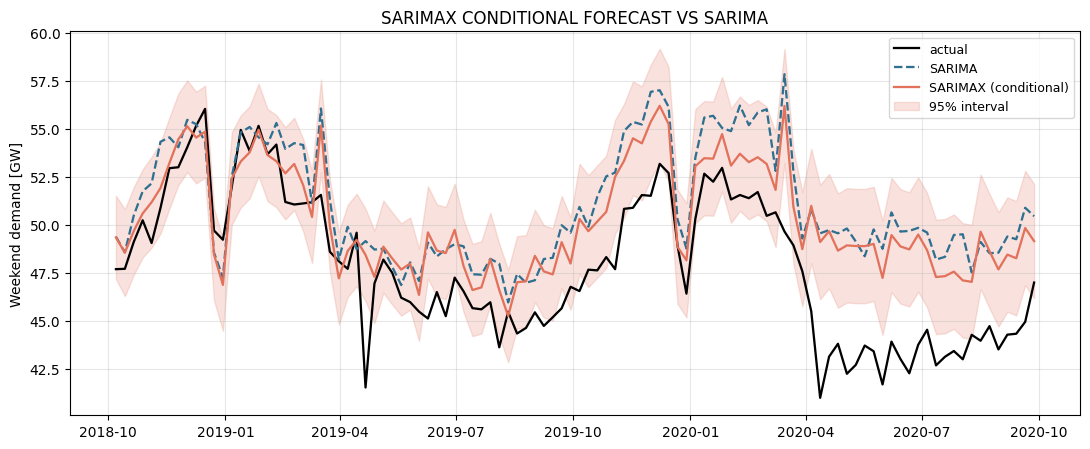

SARIMAX (conditional)        MAE 2.658  RMSE 3.266  MASE 1.807  Bias +2.455


{'model': 'SARIMAX (conditional)',
 'MAE': 2.6583278674082105,
 'RMSE': 3.2657211051794315,
 'MASE': 1.8074110703098787,
 'Bias': 2.4553301570620842}

In [19]:
# 1. reuse the order the grid chose; the weather columns become the X in SARIMAX
train_x, trial_x = xreg_w.loc[train_seg.index], xreg_w.loc[trial_seg.index]
sarimax_fit = SARIMAX(train_seg, exog=train_x, order=champ_order,
                      seasonal_order=(1, 1, 1, SEASON),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
print(f"SARIMAX{champ_order}x(1,1,1,{SEASON}) + [temp_mean, hdd, cdd] | "
      f"AIC {sarimax_fit.aic:.2f} (SARIMA was {sarima_fit.aic:.2f})")

# 2. conditional forecast: the trial exog carries observed weather
sx_view = sarimax_fit.get_forecast(steps=SPAN, exog=trial_x)
slate["SARIMAX (conditional)"] = pd.Series(sx_view.predicted_mean.values,
                                           index=trial_seg.index)
sx_band = pd.DataFrame(np.asarray(sx_view.conf_int(alpha=0.05)),
                       index=trial_seg.index, columns=["lo", "hi"])

fig, ax = plt.subplots(figsize=(THEME.fig_w, 4.6))
ax.plot(trial_seg.index, trial_seg.values, color="black", label="actual")
ax.plot(trial_seg.index, slate["SARIMA"].values, "--", color=THEME.primary,
        label="SARIMA")
ax.plot(trial_seg.index, slate["SARIMAX (conditional)"].values,
        color=THEME.secondary, label="SARIMAX (conditional)")
ax.fill_between(trial_seg.index, sx_band["lo"], sx_band["hi"],
                color=THEME.secondary, alpha=0.2, label="95% interval")
_headline_m19(ax, "SARIMAX conditional forecast vs SARIMA")
_gw_axis_m19(ax)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

post_score_m19("SARIMAX (conditional)", trial_seg, slate["SARIMAX (conditional)"])

## Feature-based machine learning (Part 5)

In [20]:
import holidays as _cal_m19

# 1. the lag and rolling picks for this member
LAG_PICKS = (1, 3, 6, 52)
ROLL_WINDOW = 8
_de_days = _cal_m19.Germany(years=range(2014, 2022))


def _week_hols_m19(ts):
    # 1. count German public holidays in the week ending at ts
    days = pd.date_range(ts - pd.Timedelta(days=6), ts, freq="D")
    return sum(d.date() in _de_days for d in days)


def _featrow_m19(hist, ts):
    """One feature row for target week ts, from history strictly before ts."""
    # 1. target lags read the past window only (this IS the shift)
    row = {f"lag_{L}": hist[-L] for L in LAG_PICKS}
    # 2. the 8-week rolling mean, also from history strictly before ts
    row[f"rollmean_{ROLL_WINDOW}"] = float(np.mean(hist[-ROLL_WINDOW:]))
    # 3. calendar: sin/cos of ISO week and the month number
    wk = ts.isocalendar().week
    row["week_sin"] = math.sin(2 * math.pi * wk / 52.0)
    row["week_cos"] = math.cos(2 * math.pi * wk / 52.0)
    row["month"] = ts.month
    # 4. weekly holiday count from a fixed calendar (known in advance)
    row["holiday_n"] = _week_hols_m19(ts)
    # 5. same-week temperature features - conditional, exactly as in Leg 4
    row["temp_mean"] = xreg_w.at[ts, "temp_mean"]
    row["hdd"] = xreg_w.at[ts, "hdd"]
    row["cdd"] = xreg_w.at[ts, "cdd"]
    return row


def supervise_m19(y):
    """Training design matrix over every week with a full 52-week history."""
    rows, targets, stamps = [], [], []
    vals = y.values
    for i in range(SEASON, len(y)):
        rows.append(_featrow_m19(vals[:i], y.index[i]))
        targets.append(vals[i])
        stamps.append(y.index[i])
    return pd.DataFrame(rows, index=stamps), pd.Series(targets, index=stamps)


X_train, y_train = supervise_m19(train_seg)
print(f"training table: {X_train.shape[0]} rows x {X_train.shape[1]} features")
print(list(X_train.columns))

training table: 144 rows x 12 features
['lag_1', 'lag_3', 'lag_6', 'lag_52', 'rollmean_8', 'week_sin', 'week_cos', 'month', 'holiday_n', 'temp_mean', 'hdd', 'cdd']


In [21]:
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor


def tree_duo_m19(X, y, seed=RNG_SEED):
    """Fit the seeded primary/secondary boosting ensembles, return them by name."""
    duo = {
        # 1. primary: gradient boosting, a slow-learning additive ensemble
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3,
            subsample=0.9, random_state=seed),
        # 2. secondary: AdaBoost over shallow trees, a different boosting flavour
        "AdaBoost": AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=4, random_state=seed),
            n_estimators=400, learning_rate=0.05, random_state=seed),
    }
    for name, mdl in duo.items():
        mdl.fit(X, y)
    return duo


def roll_ahead_m19(model, cols):
    """Genuine 104-week recursive rollout: each prediction becomes history."""
    hist = list(train_seg.values)
    path = []
    for ts in trial_seg.index:
        feats = _featrow_m19(np.asarray(hist), ts)
        x = pd.DataFrame([feats], index=[ts])[cols]
        yhat = float(model.predict(x)[0])
        path.append(yhat)
        # the guard again: the PREDICTION goes into history, never the actual
        hist.append(yhat)
    return pd.Series(path, index=trial_seg.index)


duo = tree_duo_m19(X_train, y_train)
for name, mdl in duo.items():
    slate[f"{name} (recursive)"] = roll_ahead_m19(mdl, list(X_train.columns))
    post_score_m19(f"{name} (recursive)", trial_seg, slate[f"{name} (recursive)"])

GradientBoosting (recursive) MAE 2.019  RMSE 2.535  MASE 1.373  Bias +1.272
AdaBoost (recursive)         MAE 1.805  RMSE 2.278  MASE 1.227  Bias +1.058


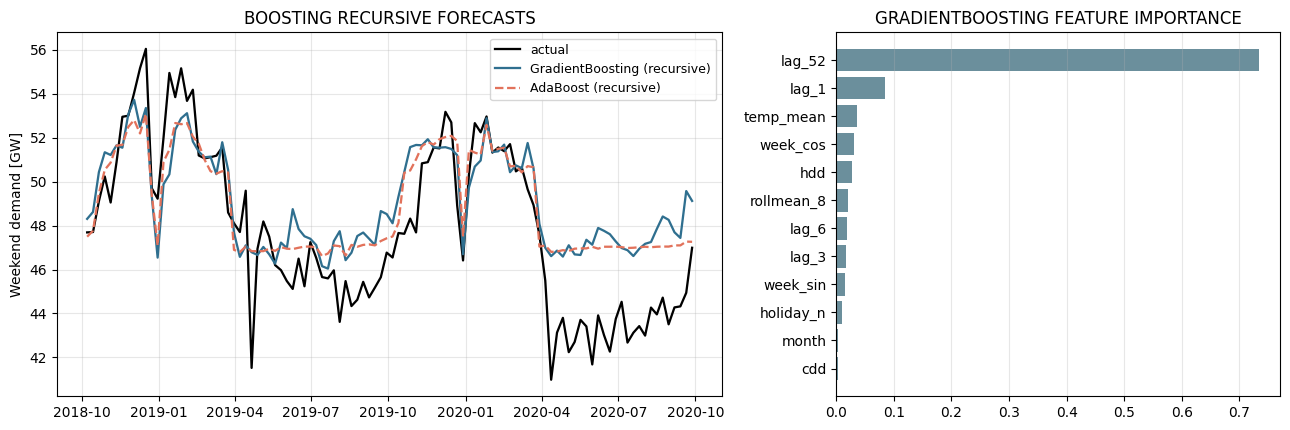

lag_52        0.7341
lag_1         0.0846
temp_mean     0.0356
week_cos      0.0311
hdd           0.0279
rollmean_8    0.0210
lag_6         0.0187
lag_3         0.0168
week_sin      0.0143
holiday_n     0.0098
month         0.0034
cdd           0.0028


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(THEME.fig_w + 2, 4.4),
                         gridspec_kw={"width_ratios": [3, 2]})
# 1. the two recursive forecasts against the actual
axes[0].plot(trial_seg.index, trial_seg.values, color="black", label="actual")
axes[0].plot(trial_seg.index, slate["GradientBoosting (recursive)"].values,
             color=THEME.primary, label="GradientBoosting (recursive)")
axes[0].plot(trial_seg.index, slate["AdaBoost (recursive)"].values, "--",
             color=THEME.secondary, label="AdaBoost (recursive)")
_headline_m19(axes[0], "Boosting recursive forecasts")
_gw_axis_m19(axes[0])
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# 2. the primary model's feature importance ranking
weights = pd.Series(duo["GradientBoosting"].feature_importances_,
                    index=X_train.columns).sort_values()
axes[1].barh(weights.index, weights.values, color=THEME.supports[0])
_headline_m19(axes[1], "GradientBoosting feature importance")
axes[1].grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()
print(weights.sort_values(ascending=False).round(4).to_string())

## LSTM on the hourly series (Part 6)

In [23]:
import tensorflow as tf
from numpy.lib.stride_tricks import sliding_window_view

# 1. the hourly fence sits where the first trial week begins (its Monday, 00:00)
fence = trial_seg.index[0].normalize() - pd.Timedelta(days=6)
hours_train = load_h[load_h.index < fence].dropna()
hours_trial = load_h[load_h.index >= fence].dropna()
print(f"hourly train: {len(hours_train):,} h | hourly trial: {len(hours_trial):,} h "
      f"| fence {fence}")

# 2. the scaler learns from TRAINING hours only, never the trial window
MU, SD = float(hours_train.mean()), float(hours_train.std())
train_scaled = ((hours_train - MU) / SD).values.astype("float32")


def _window_bank_m19(arr, look_back=LOOKBACK):
    """Sliding (n, look_back, 1) window bank plus next-step targets."""
    sled = sliding_window_view(arr, look_back + 1)
    X = sled[:, :look_back][..., None]
    y = sled[:, look_back]
    return X, y


X_bank, y_bank = _window_bank_m19(train_scaled)
n_val = int(len(X_bank) * 0.1)                 # the last 10% of training validates
X_fit, y_fit = X_bank[:-n_val], y_bank[:-n_val]
X_val, y_val = X_bank[-n_val:], y_bank[-n_val:]
print(f"window bank: fit {X_fit.shape} | val {X_val.shape}")

hourly train: 32,854 h | hourly trial: 17,546 h | fence 2018-10-01 00:00:00
window bank: fit (29418, 168, 1) | val (3268, 168, 1)


In [24]:
SWEEP_EPOCHS = 6
def build_net_m19(depth, units, dropout, lr):
    """One or two stacked LSTM layers - the depth is one axis of the sweep."""
    layers = [tf.keras.layers.Input(shape=(LOOKBACK, 1))]
    # 1. a first return-sequences layer only when depth is 2
    if depth == 2:
        layers.append(tf.keras.layers.LSTM(units, return_sequences=True))
        layers.append(tf.keras.layers.Dropout(dropout))
    # 2. the final LSTM layer plus dropout and a scalar head
    layers.append(tf.keras.layers.LSTM(units))
    layers.append(tf.keras.layers.Dropout(dropout))
    layers.append(tf.keras.layers.Dense(1))
    net = tf.keras.Sequential(layers)
    net.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="mse")
    return net


# 3. the full grid: units x dropout x learning-rate x depth = 16 candidates
sweep_rows = []
best_val, best_net, best_design = np.inf, None, None
for depth in (1, 2):
    for units in (32, 80):
        for dropout in (0.2, 0.4):
            for lr in (1e-3, 3e-4):
                net = build_net_m19(depth, units, dropout, lr)
                trace = net.fit(
                    X_fit, y_fit, validation_data=(X_val, y_val),
                    epochs=SWEEP_EPOCHS, batch_size=256,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        patience=2, restore_best_weights=True)],
                    verbose=0)
                v = float(min(trace.history["val_loss"]))
                sweep_rows.append({"depth": depth, "units": units, "dropout": dropout,
                                   "lr": lr, "val_mse": v,
                                   "epochs_run": len(trace.history["loss"])})
                print(f"depth={depth} units={units} dropout={dropout} lr={lr:g} "
                      f"-> val MSE {v:.5f}")
                if v < best_val:
                    best_val, best_net = v, net
                    best_design = {"depth": depth, "units": units,
                                   "dropout": dropout, "lr": lr}

print("\nsweep summary (all 16 candidates):")
print(pd.DataFrame(sweep_rows).sort_values("val_mse").round(5).to_string(index=False))
print(f"selected: {best_design} (val MSE {best_val:.5f})")

depth=1 units=32 dropout=0.2 lr=0.001 -> val MSE 0.01823
depth=1 units=32 dropout=0.2 lr=0.0003 -> val MSE 0.02568
depth=1 units=32 dropout=0.4 lr=0.001 -> val MSE 0.02136
depth=1 units=32 dropout=0.4 lr=0.0003 -> val MSE 0.03665
depth=1 units=80 dropout=0.2 lr=0.001 -> val MSE 0.01325
depth=1 units=80 dropout=0.2 lr=0.0003 -> val MSE 0.02278
depth=1 units=80 dropout=0.4 lr=0.001 -> val MSE 0.01509
depth=1 units=80 dropout=0.4 lr=0.0003 -> val MSE 0.02585
depth=2 units=32 dropout=0.2 lr=0.001 -> val MSE 0.01428
depth=2 units=32 dropout=0.2 lr=0.0003 -> val MSE 0.02594
depth=2 units=32 dropout=0.4 lr=0.001 -> val MSE 0.02717
depth=2 units=32 dropout=0.4 lr=0.0003 -> val MSE 0.02940
depth=2 units=80 dropout=0.2 lr=0.001 -> val MSE 0.01405
depth=2 units=80 dropout=0.2 lr=0.0003 -> val MSE 0.02218
depth=2 units=80 dropout=0.4 lr=0.001 -> val MSE 0.01758
depth=2 units=80 dropout=0.4 lr=0.0003 -> val MSE 0.02647

sweep summary (all 16 candidates):
 depth  units  dropout     lr  val_mse  epoc

In [25]:
# 1. one compiled graph call per step with a frozen TensorSpec beats a per-step
#    model.predict over ~17k steps by roughly ten times
@tf.function(input_signature=[tf.TensorSpec(shape=(1, LOOKBACK, 1), dtype=tf.float32)])
def _compiled_call_m19(window):
    return best_net(window, training=False)


def rollout_m19(seed_window, n_steps, log_every=2000):
    """True free-run rollout on a numpy ring: predictions in, actuals never."""
    buf = np.asarray(seed_window, dtype="float32").copy()
    path = np.empty(n_steps, dtype="float32")
    t0 = time.time()
    for i in range(n_steps):
        yhat = float(_compiled_call_m19(buf.reshape(1, LOOKBACK, 1))[0, 0])
        path[i] = yhat
        # 2. slide the ring forward and drop the prediction on the end
        buf = np.roll(buf, -1)
        buf[-1] = yhat
        if (i + 1) % log_every == 0:
            pace = (time.time() - t0) / (i + 1)
            print(f"  step {i + 1:>6}/{n_steps} | {pace * 1000:.1f} ms/step "
                  f"| ETA {(n_steps - i - 1) * pace / 60:.1f} min", flush=True)
    print(f"rollout complete: {n_steps} steps in {(time.time() - t0) / 60:.1f} min")
    return path


# 3. free-run the trial horizon, un-scale, then collapse through the weekend lens
n_steps = len(hours_trial)
run_scaled = rollout_m19(train_scaled[-LOOKBACK:], n_steps)
lstm_hours = pd.Series(run_scaled * SD + MU, index=hours_trial.index, name="lstm_gw")

lstm_wk, _ = weekend_frame_m19(lstm_hours)
lstm_wk = lstm_wk.reindex(trial_seg.index).dropna()
slate["LSTM (free-run)"] = lstm_wk
post_score_m19("LSTM (free-run)", trial_seg.loc[lstm_wk.index], lstm_wk)

  step   2000/17546 | 2.8 ms/step | ETA 0.7 min
  step   4000/17546 | 2.7 ms/step | ETA 0.6 min
  step   6000/17546 | 2.7 ms/step | ETA 0.5 min
  step   8000/17546 | 2.7 ms/step | ETA 0.4 min
  step  10000/17546 | 2.7 ms/step | ETA 0.3 min
  step  12000/17546 | 2.6 ms/step | ETA 0.2 min
  step  14000/17546 | 2.6 ms/step | ETA 0.2 min
  step  16000/17546 | 2.6 ms/step | ETA 0.1 min
rollout complete: 17546 steps in 0.8 min
weekend_frame_m19: kept 104 weeks with a near-complete weekend, dropped 0 partial weeks
LSTM (free-run)              MAE 11.197  RMSE 11.800  MASE 7.613  Bias +11.197


{'model': 'LSTM (free-run)',
 'MAE': 11.197352434114093,
 'RMSE': 11.800284985395889,
 'MASE': 7.6131386935768495,
 'Bias': 11.197352434114093}

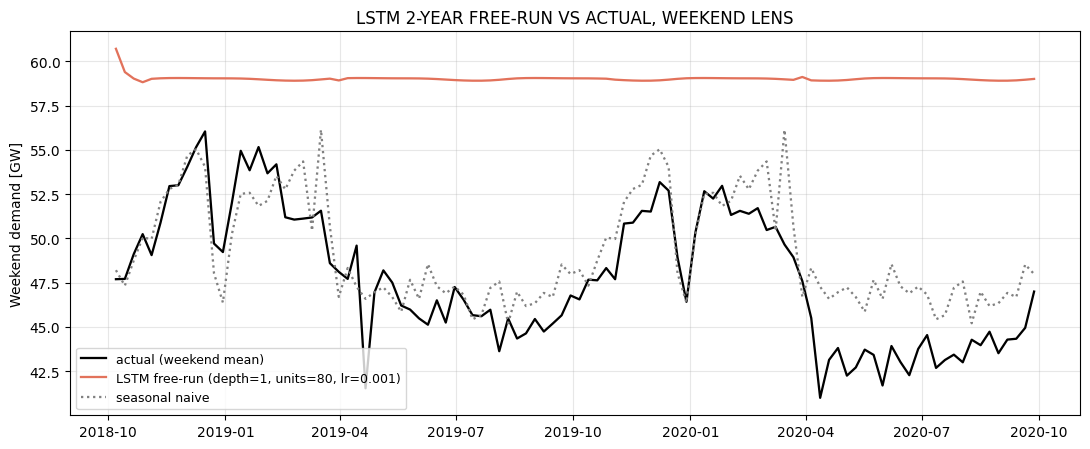

In [26]:
fig, ax = plt.subplots(figsize=(THEME.fig_w, 4.6))
ax.plot(trial_seg.index, trial_seg.values, color="black",
        label="actual (weekend mean)")
ax.plot(lstm_wk.index, lstm_wk.values, color=THEME.secondary,
        label=(f"LSTM free-run (depth={best_design['depth']}, "
               f"units={best_design['units']}, lr={best_design['lr']:g})"))
ax.plot(trial_seg.index, slate["Seasonal naive"].values, ":", color="0.5",
        label="seasonal naive")
_headline_m19(ax, "LSTM 2-year free-run vs actual, weekend lens")
_gw_axis_m19(ax)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Analysis questions (Part 7)

In [27]:
# 1. cold snaps: the five coldest trial weeks, where heating demand bites hardest
chill = xreg_w.loc[trial_seg.index, "temp_mean"].nsmallest(5).index
print("cold-snap weeks:", [str(d.date()) for d in chill],
      "| mean temp:", round(float(xreg_w.loc[chill, "temp_mean"].mean()), 1), "C")

snap_rows = []
for name, path in slate.items():
    ok = path.dropna().index.intersection(chill)
    snap_rows.append({
        "model": name,
        "cold-snap MAE": float((path.loc[ok] - trial_seg.loc[ok]).abs().mean())
        if len(ok) else np.nan,
        "overall MAE": float((path.dropna() - trial_seg.reindex(path.dropna().index))
                             .abs().mean()),
    })
snap_table = pd.DataFrame(snap_rows).set_index("model")
snap_table["snap / overall"] = (snap_table["cold-snap MAE"]
                                / snap_table["overall MAE"]).round(2)
print(snap_table.round(3).to_string())

# 2. the sweep verdict again, in one place, for the discussion below
print("\nLSTM sweep, ranked by validation MSE:")
print(pd.DataFrame(sweep_rows).sort_values("val_mse").round(5).to_string(index=False))

cold-snap weeks: ['2019-01-27', '2019-02-03', '2018-12-16', '2018-12-02', '2020-01-26'] | mean temp: 0.4 C
                              cold-snap MAE  overall MAE  snap / overall
model                                                                   
Mean                                  6.491        3.195            2.03
Naive                                 6.392        3.206            1.99
Seasonal naive                        1.730        1.952            0.89
Drift                                 6.112        3.431            1.78
SARIMA                                1.271        3.383            0.38
SARIMAX (conditional)                 0.856        2.658            0.32
GradientBoosting (recursive)          1.184        2.019            0.59
AdaBoost (recursive)                  1.626        1.805            0.90
LSTM (free-run)                       4.643       11.197            0.41

LSTM sweep, ranked by validation MSE:
 depth  units  dropout     lr  val_mse  epochs_run


## Consolidated evaluation (Part 8)

In [28]:
# 1. the consolidated scoreboard, ranked by MASE, with the ratio vs seasonal naive
table = pd.DataFrame(scoreboard).set_index("model")
ref_mase = table.at["Seasonal naive", "MASE"]
table["MASE ratio vs snaive"] = (table["MASE"] / ref_mase).round(3)
table = table.sort_values("MASE")
print(table.round(3).to_string())
print("\nmodels beating the seasonal naive (ratio < 1):",
      list(table.index[table["MASE ratio vs snaive"] < 1]))

# 2. persist the metrics and every forecast path for the report to cite
os.makedirs("outputs/forecasts", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)
table.round(4).to_csv("outputs/metrics/model_scores.csv")
pd.DataFrame({k: v for k, v in slate.items()}).to_csv(
    "outputs/forecasts/weekly_forecasts.csv")
print("saved outputs/metrics/model_scores.csv and "
      "outputs/forecasts/weekly_forecasts.csv")

                                 MAE    RMSE   MASE    Bias  MASE ratio vs snaive
model                                                                            
AdaBoost (recursive)           1.805   2.278  1.227   1.058                 0.925
Seasonal naive                 1.952   2.455  1.327   1.381                 1.000
GradientBoosting (recursive)   2.019   2.535  1.373   1.272                 1.035
SARIMAX (conditional)          2.658   3.266  1.807   2.455                 1.362
Mean                           3.195   3.721  2.172   0.063                 1.637
Naive                          3.206   3.724  2.180   0.162                 1.643
SARIMA                         3.383   3.966  2.300   3.258                 1.733
Drift                          3.431   3.991  2.333   0.755                 1.758
LSTM (free-run)               11.197  11.800  7.613  11.197                 5.737

models beating the seasonal naive (ratio < 1): ['AdaBoost (recursive)']
saved outputs/metrics/mod

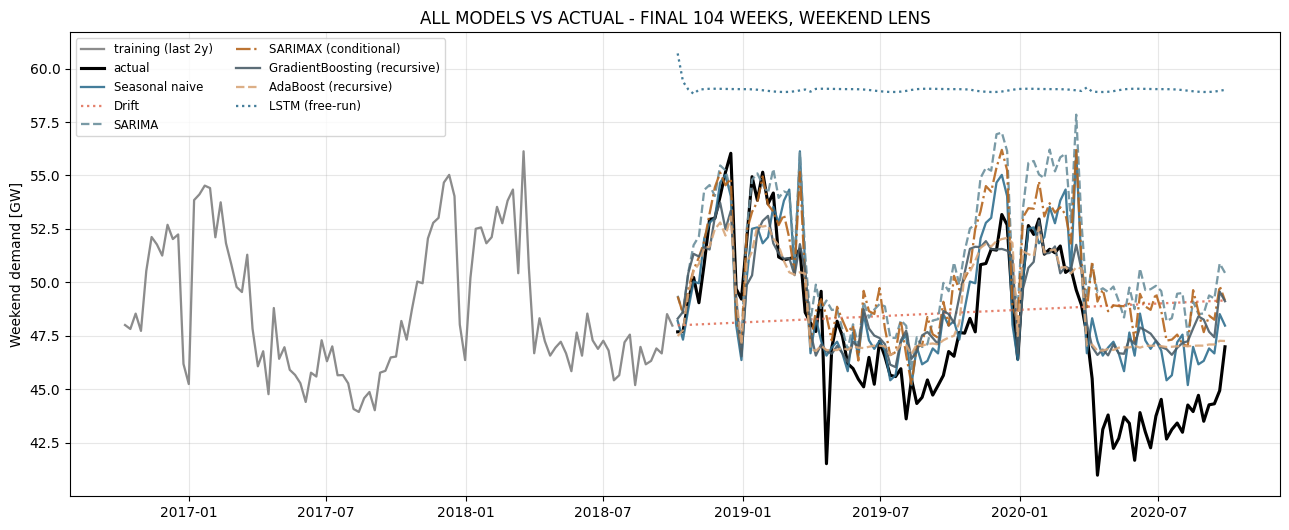

master figure saved: outputs/figures/model_comparison_master.png


In [29]:
os.makedirs("outputs/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(THEME.fig_w + 2, 5.4))
# 1. the last two training years for context
ax.plot(train_seg.index[-104:], train_seg.values[-104:], color="0.55",
        label="training (last 2y)")
ax.plot(trial_seg.index, trial_seg.values, color="black",
        lw=THEME.line_w + 0.6, label="actual")
# 2. one line per model, distinct strokes
lineup = ["Seasonal naive", "Drift", "SARIMA", "SARIMAX (conditional)",
          "GradientBoosting (recursive)", "AdaBoost (recursive)", "LSTM (free-run)"]
strokes = ["-", ":", "--", "-.", "-", "--", ":"]
for i, name in enumerate(lineup):
    path = slate[name].dropna()
    ax.plot(path.index, path.values, strokes[i], color=THEME.palette[i % len(THEME.palette)],
            label=name, alpha=0.9)
_headline_m19(ax, "All models vs actual - final 104 weeks, weekend lens")
_gw_axis_m19(ax)
ax.legend(ncol=2, fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("outputs/figures/model_comparison_master.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("master figure saved: outputs/figures/model_comparison_master.png")

In [30]:
def regime_grid_m19(paths, actual, temps):
    """MAE by regime: festive weeks, temperature extremes, and the COVID split."""
    # 1. festive ISO weeks, warmest five, coldest five
    iso_wk = pd.Index(actual.index.isocalendar().week)
    festive = actual.index[iso_wk.isin([52, 1, 2])]
    warmest = temps.nlargest(5).index
    coldest = temps.nsmallest(5).index
    print("festive weeks:", [str(d.date()) for d in festive])
    print("warmest weeks:", [str(d.date()) for d in warmest],
          "| coldest weeks:", [str(d.date()) for d in coldest])

    pivot = pd.Timestamp("2020-01-01")
    rows = []
    for name, path in paths.items():
        ok = path.dropna().index

        def mae_m19(sub):
            sub = sub.intersection(ok)
            return (float(np.mean(np.abs(path.loc[sub] - actual.loc[sub])))
                    if len(sub) else np.nan)

        rows.append({
            "model": name,
            "festive MAE": mae_m19(festive),
            "warmest-5 MAE": mae_m19(warmest),
            "coldest-5 MAE": mae_m19(coldest),
            "MAE pre-2020": mae_m19(actual.index[actual.index < pivot]),
            "MAE 2020": mae_m19(actual.index[actual.index >= pivot]),
        })
    out = pd.DataFrame(rows).set_index("model")
    out["2020 / pre-2020"] = (out["MAE 2020"] / out["MAE pre-2020"]).round(2)
    return out


regimes = regime_grid_m19(slate, trial_seg, xreg_w.loc[trial_seg.index, "temp_mean"])
print(regimes.round(3).to_string())

festive weeks: ['2018-12-30', '2019-01-06', '2019-01-13', '2019-12-29', '2020-01-05', '2020-01-12']
warmest weeks: ['2020-08-16', '2019-09-01', '2019-07-28', '2019-06-30', '2020-08-09'] | coldest weeks: ['2019-01-27', '2019-02-03', '2018-12-16', '2018-12-02', '2020-01-26']
                              festive MAE  warmest-5 MAE  coldest-5 MAE  MAE pre-2020  MAE 2020  2020 / pre-2020
model                                                                                                           
Mean                                3.531          2.506          6.491         2.794     3.862             1.38
Naive                               3.465          2.605          6.392         2.790     3.900             1.40
Seasonal naive                      1.226          1.222          1.730         1.463     2.766             1.89
Drift                               3.258          3.339          6.112         2.872     4.363             1.52
SARIMA                              1.851       

## Repository notes (Part 9)

Layout of the folder:

```
notebook.ipynb                      entry point, runs top to bottom
README.md                           aim, data, how to run, model summary
requirements.txt                    package list
berlin_daily_temperature.csv        cached Open-Meteo daily temperature
time_series_60min_singleindex.csv   OPSD load, auto-downloaded if absent
outputs/                            created at run time
    figures/                        master comparison figure
    forecasts/                      weekly forecast path per model
    metrics/                        consolidated score table
```

Reproducibility rests on a few habits: relative paths everywhere, seeds fixed
across numpy, random and TensorFlow, and functions that each do one documented
task. The `FAST_RUN` flag is `False` by default, so the full SARIMA grid from the
brief runs without extra steps, and external data is cached behind a clearly
labelled offline fallback. Metrics and forecasts are written to CSV, which lets
the report cite files rather than screenshots. To reproduce: install
`requirements.txt` on a clean runtime, then Run All.